# Loan Approval Prediction
> **Task 2** | Dhamat Yaksh  
> **Dataset:** [Loan Approval Prediction — Kaggle](https://www.kaggle.com/datasets/bhanupratapbiswas/loan-approval-prediction-case-study)  
> **Goal:** Build a supervised model to predict loan approval using borrower features. Focus on preprocessing, handling imbalance, and evaluation.

---
##  Notebook Structure
1.  Imports & Setup
2.  Load Data
3.  Raw Data Overview
4.  Data Cleaning
5.  Exploratory Data Analysis 
6.  Feature Engineering & Encoding
7.  Train/Test Split & SMOTE 
8.  Model Training & Evaluation
9.  Business Interpretation & Threshold Analysis
10. Key Findings
11. Recommendations


## 1.  Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print(' Libraries loaded!')

 Libraries loaded!


## 2.  Load Data
The dataset contains 614 loan applications with borrower demographics, income, and credit history.


In [2]:
df = pd.read_csv('loan_prediction.csv')
print(f'Shape  : {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape  : (614, 13)  (614 rows × 13 columns)
Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3.  Raw Data Overview
>  **Important:** We only inspect the raw data here — we do NOT run EDA visualizations yet.  
> EDA must happen **after** cleaning, otherwise missing values distort our charts and statistics.


In [3]:
print('── Data Types ──')
print(df.dtypes)

── Data Types ──
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [4]:
print('── Missing Values (Raw) ──')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing cells: {missing.sum()}')

── Missing Values (Raw) ──
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Total missing cells: 149


In [5]:
print('── Target Distribution (Raw) ──')
print(df['Loan_Status'].value_counts())
approved_pct = (df['Loan_Status']=='Y').sum() / len(df) * 100
print(f'Approved: {approved_pct:.1f}%  ← class imbalance present, will need SMOTE')

── Target Distribution (Raw) ──
Loan_Status
Y    422
N    192
Name: count, dtype: int64
Approved: 68.7%  ← class imbalance present, will need SMOTE


## 4.  Data Cleaning

| Column | Missing | Strategy |
|--------|---------|----------|
| Gender | 13 | Mode (most frequent) |
| Married | 3 | Mode |
| Dependents | 15 | Mode |
| Self_Employed | 32 | Mode |
| LoanAmount | 22 | Median (robust to outliers) |
| Loan_Amount_Term | 14 | Mode |
| Credit_History | 50 | Mode |

We impute rather than drop rows, with only 614 total rows, every row matters for model training


In [6]:
df_clean = df.copy()

df_clean['Gender']           = df_clean['Gender'].fillna(df_clean['Gender'].mode()[0])
df_clean['Married']          = df_clean['Married'].fillna(df_clean['Married'].mode()[0])
df_clean['Dependents']       = df_clean['Dependents'].fillna(df_clean['Dependents'].mode()[0])
df_clean['Self_Employed']    = df_clean['Self_Employed'].fillna(df_clean['Self_Employed'].mode()[0])
df_clean['LoanAmount']       = df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median())
df_clean['Loan_Amount_Term'] = df_clean['Loan_Amount_Term'].fillna(df_clean['Loan_Amount_Term'].mode()[0])
df_clean['Credit_History']   = df_clean['Credit_History'].fillna(df_clean['Credit_History'].mode()[0])

missing_after = df_clean.isnull().sum()
print(missing_after[missing_after>0] if missing_after.any() else ' No missing values — dataset is clean!')
print(f'\nRows before: {len(df)} | Rows after: {len(df_clean)}  (no rows dropped — all imputed)')

 No missing values — dataset is clean!

Rows before: 614 | Rows after: 614  (no rows dropped — all imputed)


## 5.  Exploratory Data Analysis (on Clean Data)

| # | Chart | Question it Answers |
|---|-------|---------------------|
| 1 | Target Distribution | How imbalanced is loan approval? |
| 2 | Categorical vs Status | Which borrower traits affect approval? |
| 3 | Numeric Distributions | How do income/loan amount differ by outcome? |
| 4 | Credit History Analysis | Does credit history matter most? |
| 5 | Correlation Heatmap | How do engineered features relate to approval? |


###  Viz 1 — Target Distribution

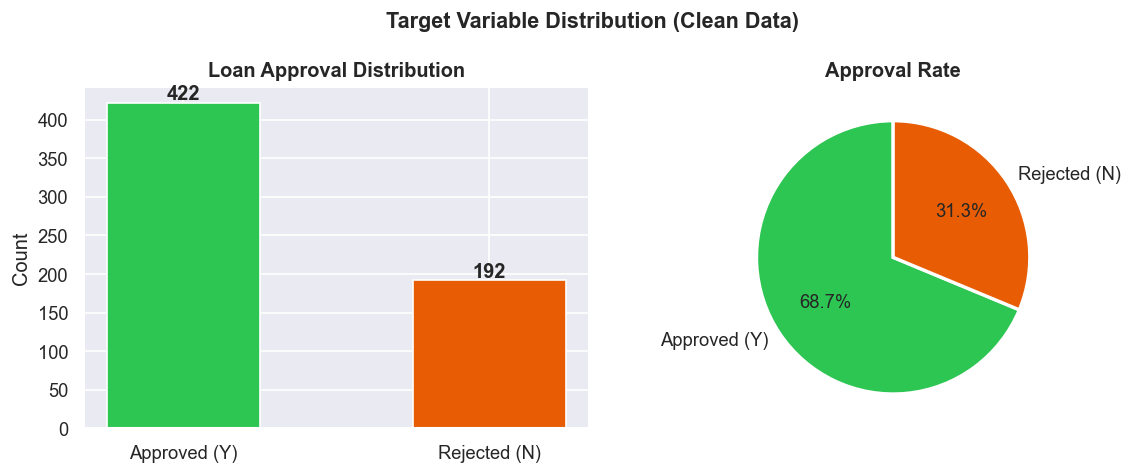

 68.7% approved vs 31.3% rejected — clear class imbalance, SMOTE needed.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df_clean['Loan_Status'].value_counts()
axes[0].bar(['Approved (Y)','Rejected (N)'], counts.values,
            color=['#2DC653','#E85D04'], edgecolor='white', width=0.5)
axes[0].set_title('Loan Approval Distribution', weight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+4, str(v), ha='center', fontsize=12, weight='bold')

axes[1].pie(counts.values, labels=['Approved (Y)','Rejected (N)'],
            colors=['#2DC653','#E85D04'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Approval Rate', weight='bold')
plt.suptitle('Target Variable Distribution (Clean Data)', fontsize=13, weight='bold')
plt.tight_layout(); plt.savefig('viz1_target_distribution.png'); plt.show()
print(' 68.7% approved vs 31.3% rejected — clear class imbalance, SMOTE needed.')

###  Viz 2 — Categorical Features vs Loan Status

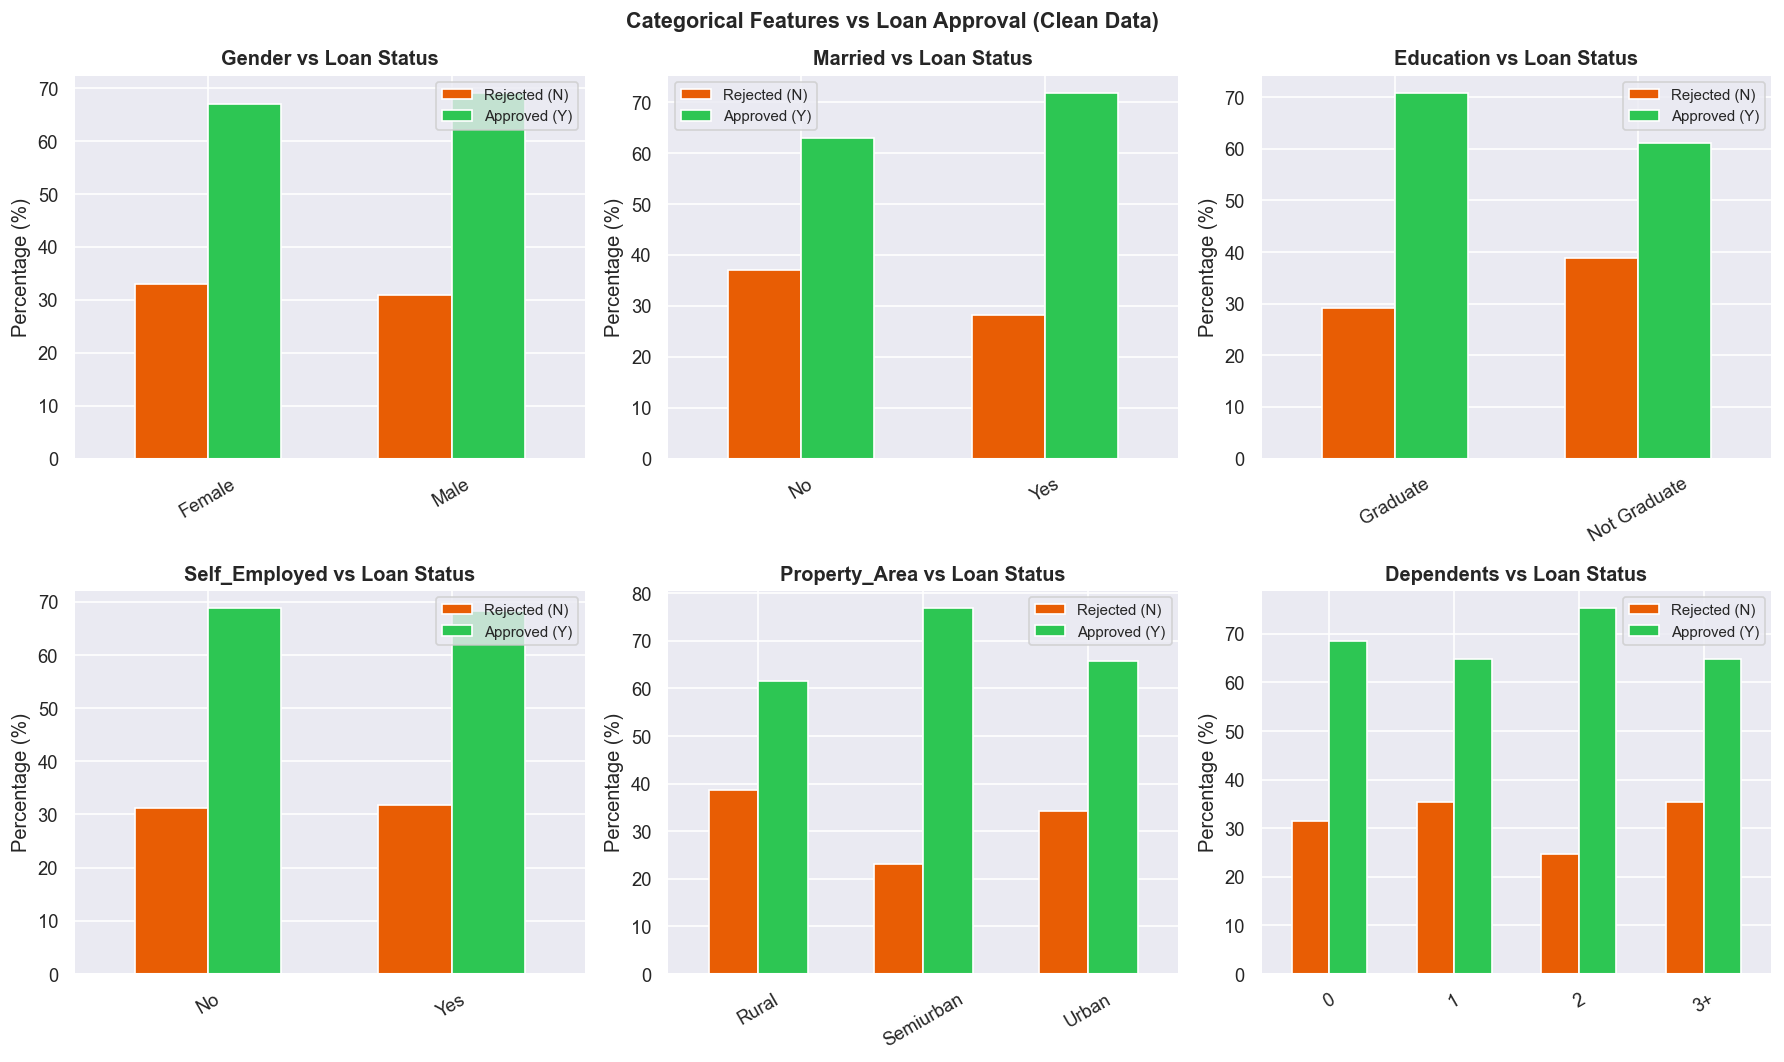

 Married applicants & Graduates show higher approval rates.


In [8]:
cat_cols = ['Gender','Married','Education','Self_Employed','Property_Area','Dependents']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df_clean[col], df_clean['Loan_Status'], normalize='index')*100
    ct.plot(kind='bar', ax=axes[i], color=['#E85D04','#2DC653'],
            edgecolor='white', rot=30, width=0.6)
    axes[i].set_title(f'{col} vs Loan Status', weight='bold')
    axes[i].set_ylabel('Percentage (%)'); axes[i].set_xlabel('')
    axes[i].legend(['Rejected (N)','Approved (Y)'], fontsize=9)
plt.suptitle('Categorical Features vs Loan Approval (Clean Data)', fontsize=13, weight='bold')
plt.tight_layout(); plt.savefig('viz2_categorical_vs_loan_status.png'); plt.show()
print(' Married applicants & Graduates show higher approval rates.')

###  Viz 3 — Numeric Feature Distributions

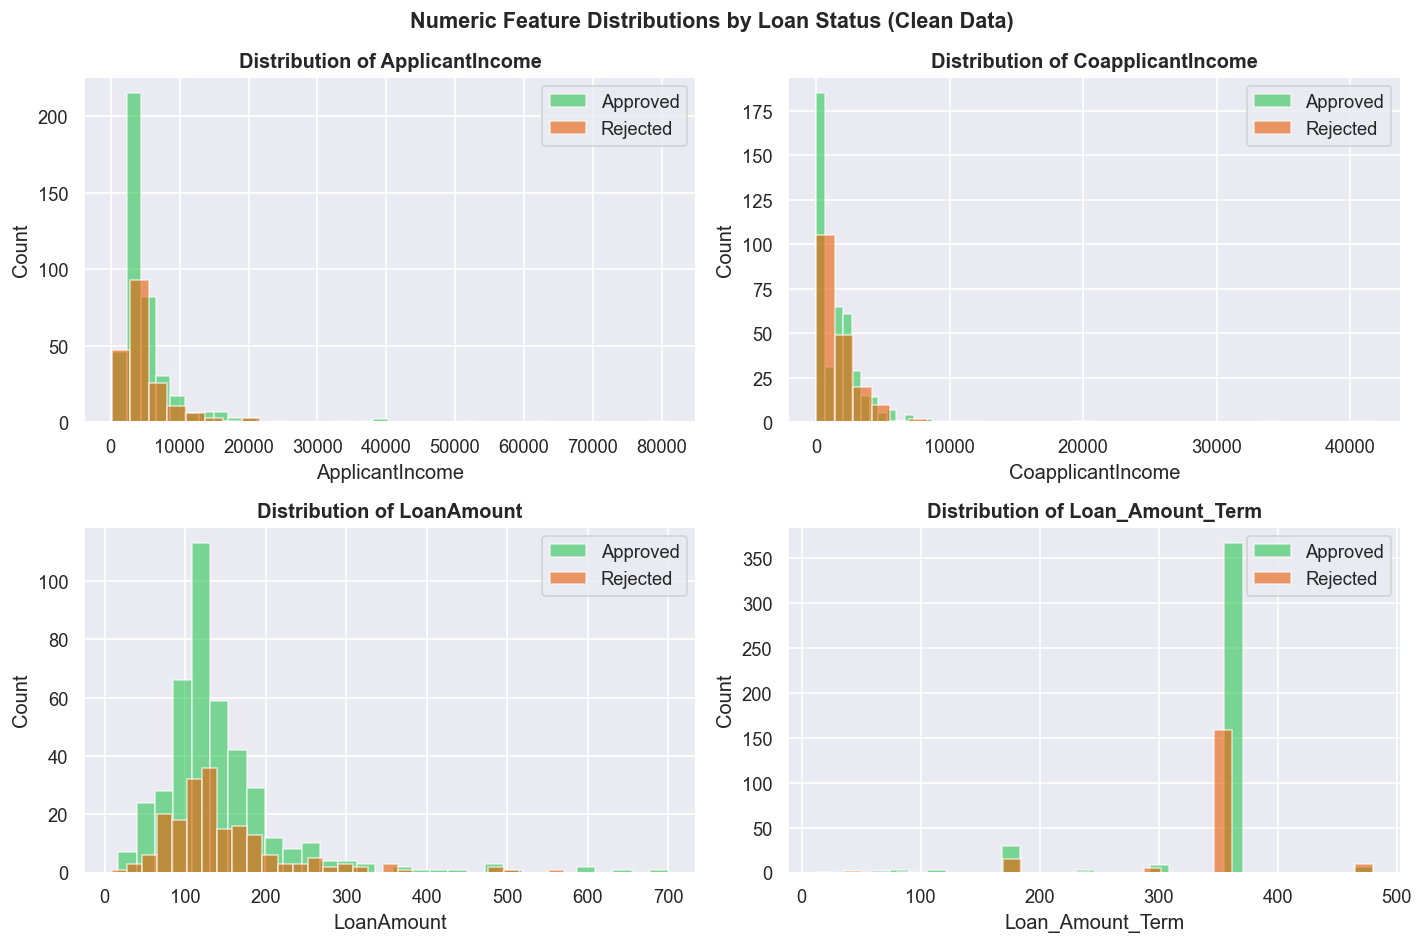

 Approved loans skew toward lower-to-mid loan amounts.


In [9]:
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for status, color, label in [('Y','#2DC653','Approved'), ('N','#E85D04','Rejected')]:
        data = df_clean[df_clean['Loan_Status']==status][col]
        axes[i].hist(data, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', weight='bold')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Count'); axes[i].legend()
plt.suptitle('Numeric Feature Distributions by Loan Status (Clean Data)', fontsize=13, weight='bold')
plt.tight_layout(); plt.savefig('viz3_numeric_distributions.png'); plt.show()
print(' Approved loans skew toward lower-to-mid loan amounts.')

###  Viz 4 — Credit History Analysis

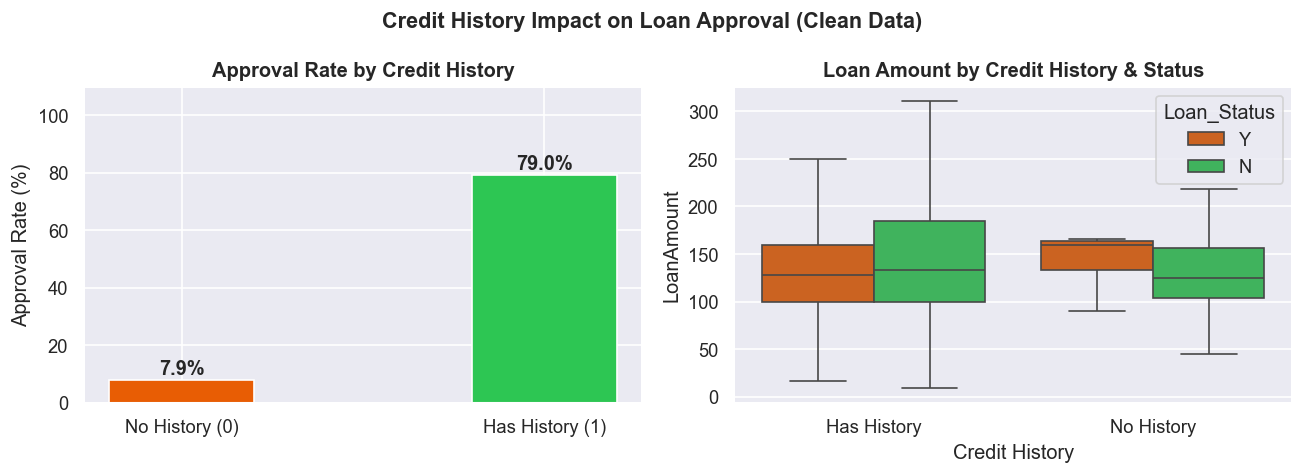

 Credit History is the single strongest predictor — 80%+ approval with history vs ~8% without.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ch_approval = df_clean.groupby('Credit_History')['Loan_Status'].apply(
    lambda x: (x=='Y').sum()/len(x)*100).reset_index()
ch_approval.columns = ['Credit_History','Approval_Rate']
ch_approval['Credit_History'] = ch_approval['Credit_History'].map({0.0:'No History (0)', 1.0:'Has History (1)'})

axes[0].bar(ch_approval['Credit_History'], ch_approval['Approval_Rate'],
            color=['#E85D04','#2DC653'], edgecolor='white', width=0.4)
axes[0].set_title('Approval Rate by Credit History', weight='bold')
axes[0].set_ylabel('Approval Rate (%)'); axes[0].set_ylim(0,110)
for i, v in enumerate(ch_approval['Approval_Rate']):
    axes[0].text(i, v+2, f'{v:.1f}%', ha='center', fontsize=12, weight='bold')

df_clean['Credit_History_Label'] = df_clean['Credit_History'].map({0.0:'No History', 1.0:'Has History'})
sns.boxplot(data=df_clean, x='Credit_History_Label', y='LoanAmount', hue='Loan_Status',
            palette=['#E85D04','#2DC653'], ax=axes[1], showfliers=False)
axes[1].set_title('Loan Amount by Credit History & Status', weight='bold')
axes[1].set_xlabel('Credit History')

plt.suptitle('Credit History Impact on Loan Approval (Clean Data)', fontsize=13, weight='bold')
plt.tight_layout(); plt.savefig('viz4_credit_history_analysis.png'); plt.show()
print(' Credit History is the single strongest predictor — 80%+ approval with history vs ~8% without.')

## 6.  Feature Engineering & Encoding

| New Feature | Formula | Why |
|-------------|---------|-----|
| `Total_Income` | ApplicantIncome + CoapplicantIncome | Household income matters more than individual |
| `LoanAmount_log` | log(LoanAmount) | Reduces right-skewness |
| `Total_Income_log` | log(Total_Income) | Reduces right-skewness |
| `EMI` | LoanAmount / Loan_Amount_Term | Monthly burden proxy |
| `Balance_Income` | Total_Income − (EMI × 1000) | Disposable income after loan payment |


In [11]:
df_ml = df_clean.copy()

df_ml['Total_Income']     = df_ml['ApplicantIncome'] + df_ml['CoapplicantIncome']
df_ml['LoanAmount_log']   = np.log1p(df_ml['LoanAmount'])
df_ml['Total_Income_log'] = np.log1p(df_ml['Total_Income'])
df_ml['EMI']              = df_ml['LoanAmount'] / df_ml['Loan_Amount_Term']
df_ml['Balance_Income']   = df_ml['Total_Income'] - (df_ml['EMI'] * 1000)

print(' New features created.')
df_ml[['Total_Income','LoanAmount_log','Total_Income_log','EMI','Balance_Income']].head()

 New features created.


,Total_Income,LoanAmount_log,Total_Income_log,EMI,Balance_Income
0,5849.0,4.859812,8.674197,0.355556,5493.444444
1,6091.0,4.859812,8.714732,0.355556,5735.444444
2,3000.0,4.204693,8.006701,0.183333,2816.666667
3,4941.0,4.795791,8.505525,0.333333,4607.666667
4,6000.0,4.955827,8.699681,0.391667,5608.333333


In [12]:
# Label Encoding for categorical columns
le = LabelEncoder()
encode_cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area']
for col in encode_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Target: Y → 1, N → 0
df_ml['Loan_Status'] = df_ml['Loan_Status'].map({'Y': 1, 'N': 0})
print(' Label encoding done.')

 Label encoding done.


###  Viz 5 — Correlation Heatmap

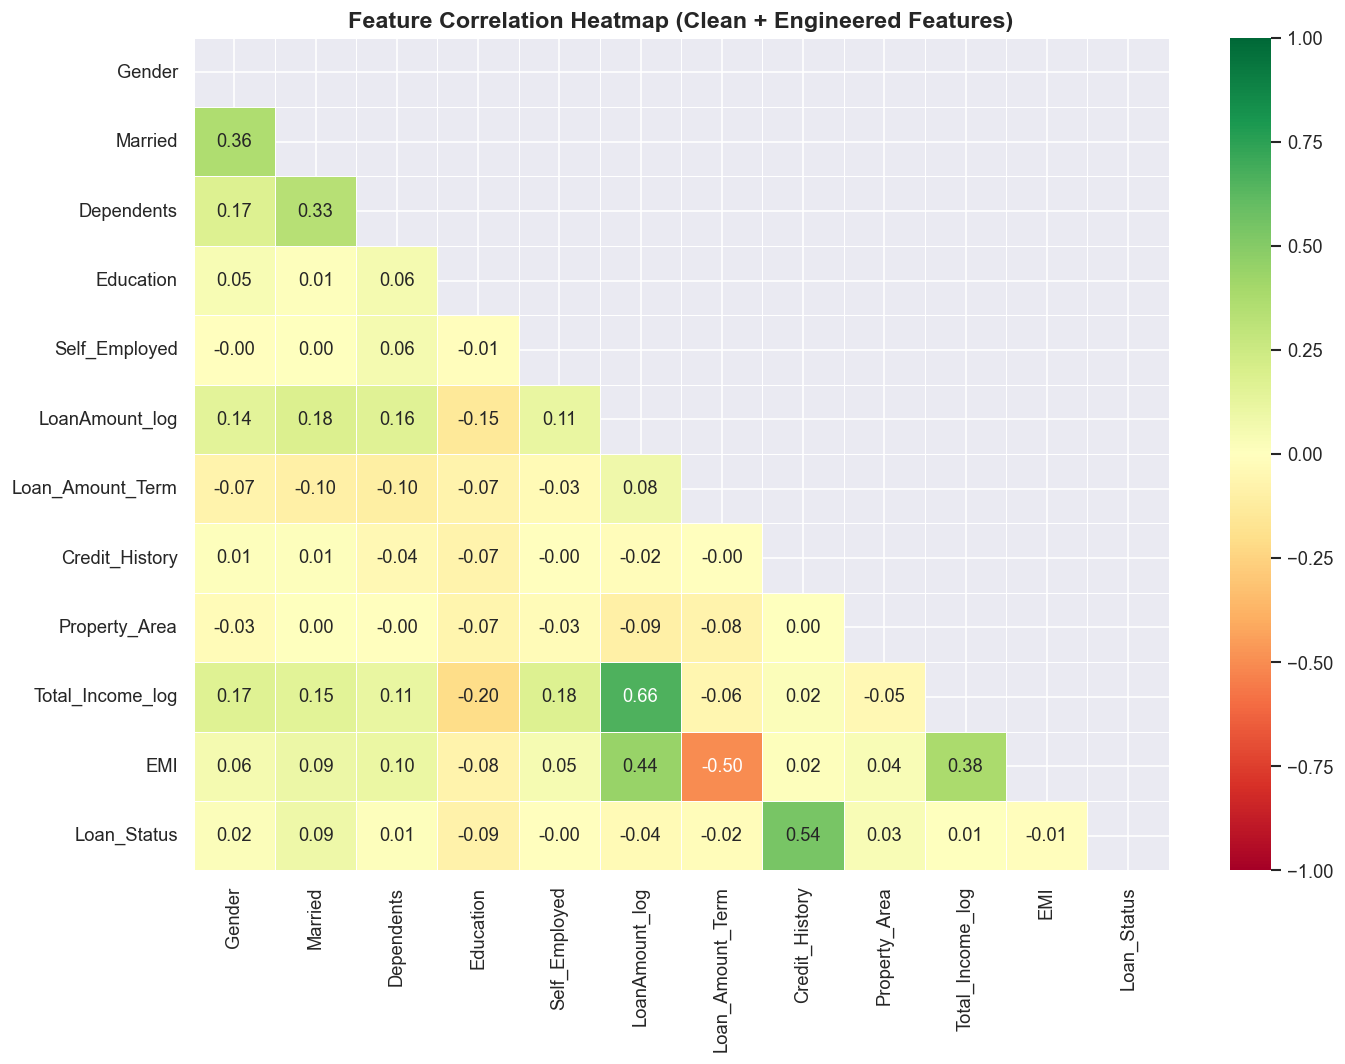

 Credit_History shows by far the strongest correlation with Loan_Status.


In [13]:
heatmap_cols = ['Gender','Married','Dependents','Education','Self_Employed',
                'LoanAmount_log','Loan_Amount_Term','Credit_History','Property_Area',
                'Total_Income_log','EMI','Loan_Status']

fig, ax = plt.subplots(figsize=(12, 9))
corr = df_ml[heatmap_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap (Clean + Engineered Features)', fontsize=14, weight='bold')
plt.tight_layout(); plt.savefig('viz5_correlation_heatmap.png'); plt.show()
print(' Credit_History shows by far the strongest correlation with Loan_Status.')

## 7.  Train/Test Split & SMOTE (Leakage-Safe)

###  Critical: Avoiding Data Leakage

**The wrong way:** Apply SMOTE to the entire dataset, then split into train/test.  
**Why it's wrong:** Synthetic points get created using neighbors that may end up in your test set. Test set information leaks into training — the model partially memorizes the test set rather than generalizing, inflating Accuracy and ROC-AUC.

**The correct way:**
1. Split data into train/test FIRST
2. Apply SMOTE ONLY to the training set
3. Leave the test set **untouched and imbalanced** — it represents real-world data
4. Scale: fit scaler on training data, transform test data


In [14]:
feature_cols = ['Gender','Married','Dependents','Education','Self_Employed',
                'LoanAmount_log','Loan_Amount_Term','Credit_History','Property_Area',
                'Total_Income_log','EMI','Balance_Income']

X = df_ml[feature_cols]
y = df_ml['Loan_Status']

# 1. SPLIT FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train set — Approved: {sum(y_train==1)} | Rejected: {sum(y_train==0)}')
print(f'Test set  — Approved: {sum(y_test==1)}  | Rejected: {sum(y_test==0)}')
print('Test set is kept IMBALANCED — represents real-world distribution')

Train set — Approved: 337 | Rejected: 154
Test set  — Approved: 85  | Rejected: 38
Test set is kept IMBALANCED — represents real-world distribution


In [15]:
# 2. SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Training set after SMOTE — Approved: {sum(y_train_res==1)} | Rejected: {sum(y_train_res==0)}')

Training set after SMOTE — Approved: 337 | Rejected: 337


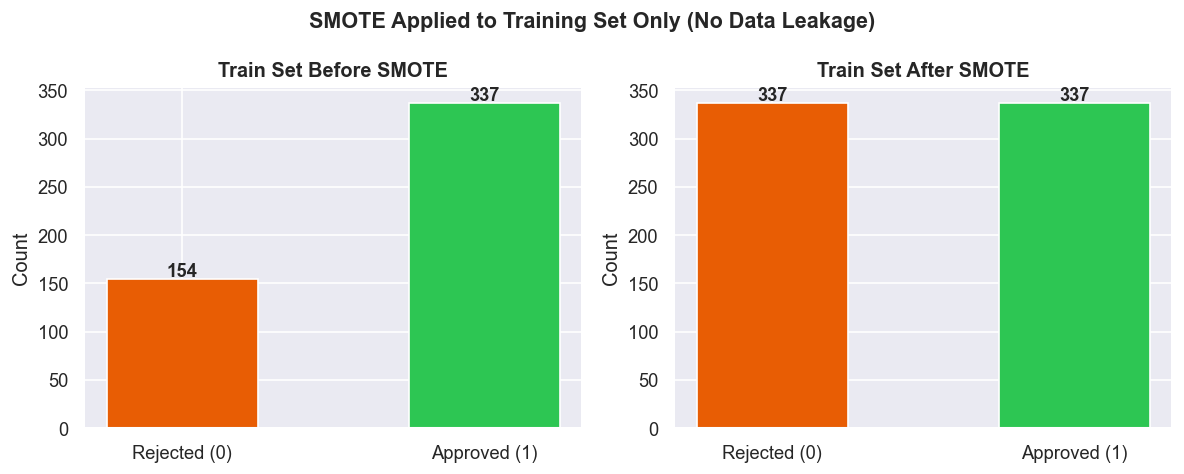

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, title) in zip(axes, [
    (y_train,     'Train Set Before SMOTE'),
    (y_train_res, 'Train Set After SMOTE'),
]):
    counts = pd.Series(data).value_counts().sort_index()
    ax.bar(['Rejected (0)','Approved (1)'], counts.values,
           color=['#E85D04','#2DC653'], edgecolor='white', width=0.5)
    ax.set_title(title, weight='bold'); ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v+3, str(v), ha='center', fontsize=11, weight='bold')
plt.suptitle('SMOTE Applied to Training Set Only (No Data Leakage)', fontsize=13, weight='bold')
plt.tight_layout(); plt.savefig('viz6_smote_balance.png'); plt.show()

In [17]:
# 3. Scale — fit on resampled train, transform test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

print(f'Train (after SMOTE): {X_train_res.shape[0]} | Test: {X_test.shape[0]}')
print(' Split, SMOTE, and scaling done correctly — no leakage.')

Train (after SMOTE): 674 | Test: 123
 Split, SMOTE, and scaling done correctly — no leakage.


## 8.  Model Training & Evaluation

**Models tested:**
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- SVM

**Metrics:** Accuracy, Precision, Recall, F1 Score, ROC-AUC — evaluated on the **untouched, imbalanced test set**.


In [18]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting',   GradientBoostingClassifier(random_state=42)),
    ('SVM',                 SVC(probability=True, random_state=42)),
]

results  = []
roc_data = {}

for name, model in models:
    model.fit(X_train_sc, y_train_res)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred),    4),
        'F1 Score' : round(f1_score(y_test, y_pred),        4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
    })
    roc_data[name] = (y_prob, model)
    print(f'   {name:25s} Acc={results[-1]["Accuracy"]:.3f} | F1={results[-1]["F1 Score"]:.3f} | AUC={results[-1]["ROC-AUC"]:.3f}')

results_df = pd.DataFrame(results)
print('\n── Full Results ──')
results_df

   Logistic Regression       Acc=0.846 | F1=0.890 | AUC=0.846
   Decision Tree             Acc=0.772 | F1=0.833 | AUC=0.708
   Random Forest             Acc=0.764 | F1=0.824 | AUC=0.817
   Gradient Boosting         Acc=0.789 | F1=0.849 | AUC=0.799
   SVM                       Acc=0.813 | F1=0.872 | AUC=0.779

── Full Results ──


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8455,0.8750,0.9059,0.8902,0.8455
1,Decision Tree,0.7724,0.8434,0.8235,0.8333,0.7079
2,Random Forest,0.7642,0.8500,0.8000,0.8242,0.8172
3,Gradient Boosting,0.7886,0.8391,0.8588,0.8488,0.7988
4,SVM,0.8130,0.8298,0.9176,0.8715,0.7789


###  Viz 6 — Model Comparison & ROC Curves

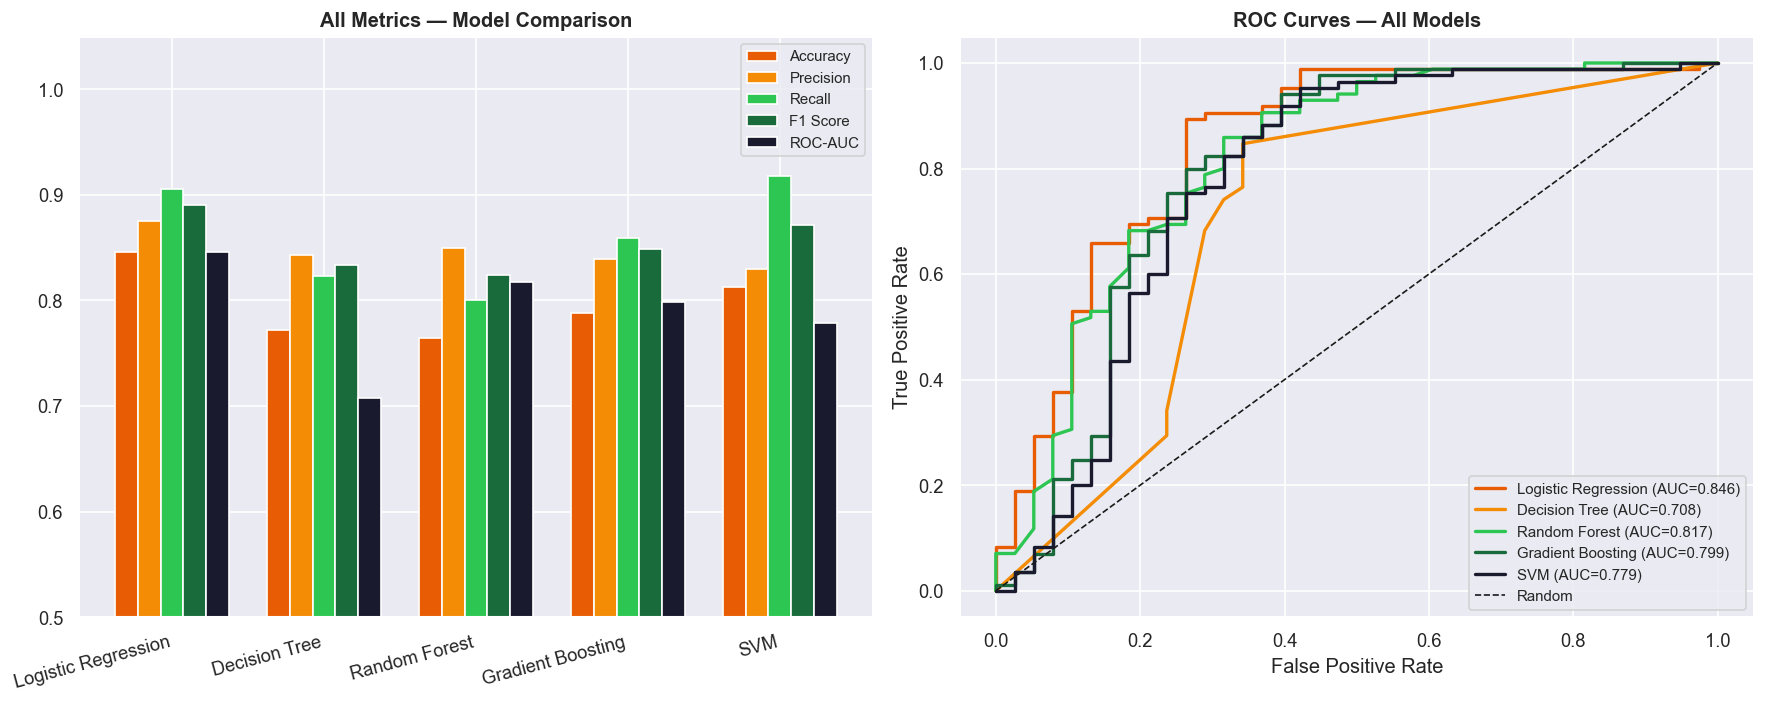

 Best by ROC-AUC: Logistic Regression (0.8455)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

metrics = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']
x = np.arange(len(results_df)); w = 0.15
colors = ['#E85D04','#F48C06','#2DC653','#1A6B3C','#1A1A2E']
for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[0].bar(x + i*w, results_df[metric], width=w, label=metric, color=color, edgecolor='white')
axes[0].set_xticks(x + 2*w)
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[0].set_title('All Metrics — Model Comparison', weight='bold')
axes[0].set_ylim(0.5, 1.05); axes[0].legend(fontsize=9)

roc_colors = ['#E85D04','#F48C06','#2DC653','#1A6B3C','#1A1A2E']
for (name, (y_prob, _)), color in zip(roc_data.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = results_df[results_df['Model']==name]['ROC-AUC'].values[0]
    axes[1].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc_val:.3f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random')
axes[1].set_title('ROC Curves — All Models', weight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9); axes[1].grid(True)
plt.tight_layout(); plt.savefig('viz7_model_comparison_roc.png'); plt.show()

best_auc_row = results_df.loc[results_df['ROC-AUC'].idxmax()]
print(f" Best by ROC-AUC: {best_auc_row['Model']} ({best_auc_row['ROC-AUC']:.4f})")

###  Viz 7 — Feature Importance (Random Forest)

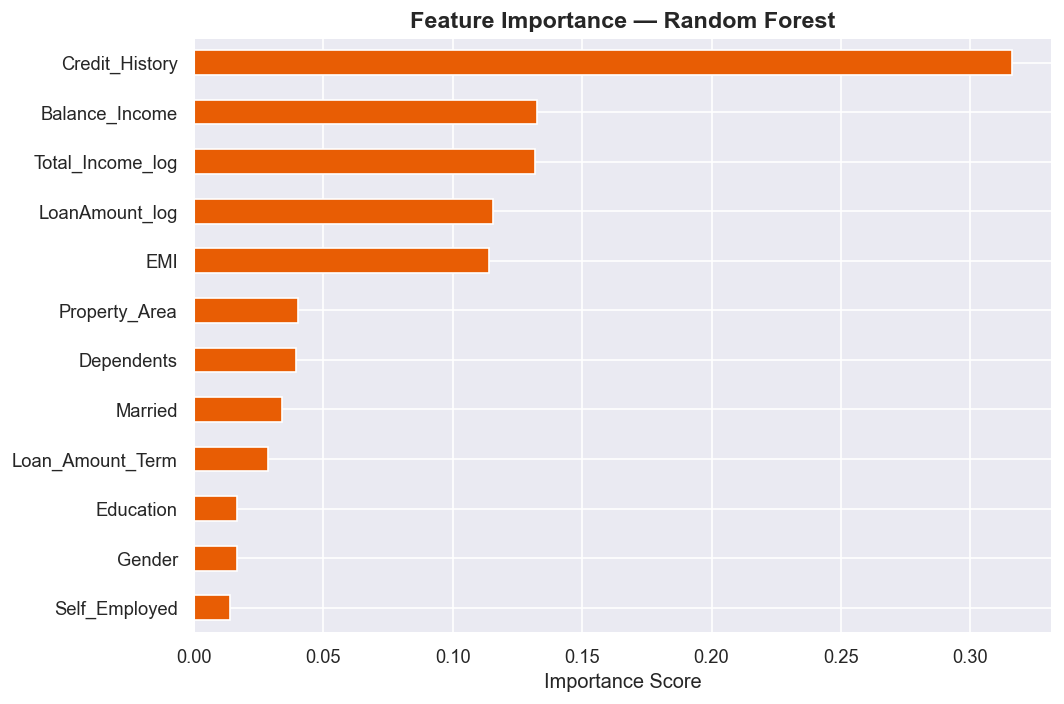

 Credit_History dominates — by far the most important predictor.


In [20]:
best_rf = [m for n, m in models if n == 'Random Forest'][0]
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='#E85D04', edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=14, weight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.savefig('viz8_feature_importance.png'); plt.show()
print(' Credit_History dominates — by far the most important predictor.')

###  Viz 8 — Confusion Matrix (Best Model)

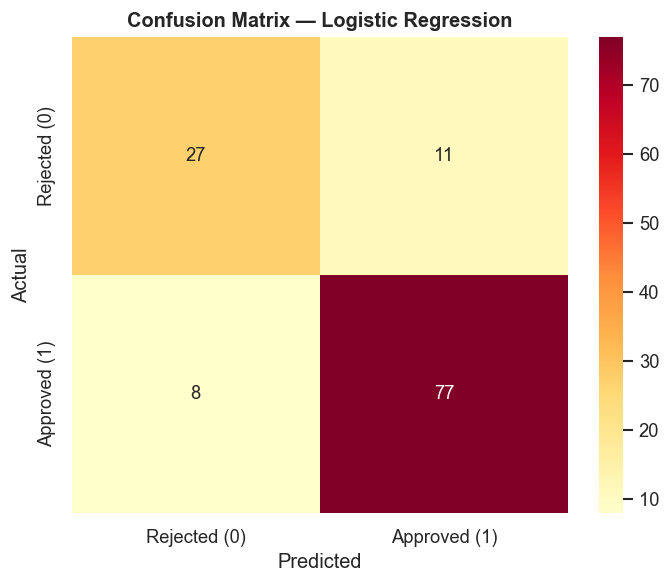

In [21]:
best_name  = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']
best_model = [m for n, m in models if n == best_name][0]
y_pred_best = best_model.predict(X_test_sc)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            xticklabels=['Rejected (0)','Approved (1)'],
            yticklabels=['Rejected (0)','Approved (1)'])
ax.set_title(f'Confusion Matrix — {best_name}', weight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.savefig('viz9_confusion_matrix.png'); plt.show()

## 9.  Business Interpretation & Threshold Analysis

In a real lending platform, the prediction threshold (default 0.5) can be tuned based on business priorities:
- **Lower threshold** → approve more loans → higher recall, more risk
- **Higher threshold** → approve fewer loans → higher precision, more conservative


In [22]:
best_auc_name  = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_auc_model = [m for n, m in models if n == best_auc_name][0]
y_probs = best_auc_model.predict_proba(X_test_sc)[:, 1]

print(f'Best model by ROC-AUC: {best_auc_name}\n')
print('Classification Report (threshold=0.5):')
print(classification_report(y_test, best_auc_model.predict(X_test_sc),
      target_names=['Rejected (N)','Approved (Y)']))

Best model by ROC-AUC: Logistic Regression

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

Rejected (N)       0.77      0.71      0.74        38
Approved (Y)       0.88      0.91      0.89        85

    accuracy                           0.85       123
   macro avg       0.82      0.81      0.81       123
weighted avg       0.84      0.85      0.84       123



In [23]:
print('── Threshold Analysis ──')
print(f'{"Threshold":>10} {"Precision":>10} {"Recall":>10} {"F1":>8} {"Approved%":>10}')
threshold_results = []
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_t = (y_probs >= thresh).astype(int)
    p = precision_score(y_test, y_t, zero_division=0)
    r = recall_score(y_test, y_t, zero_division=0)
    f = f1_score(y_test, y_t, zero_division=0)
    pct = y_t.mean() * 100
    threshold_results.append([thresh, p, r, f, pct])
    print(f'{thresh:>10.1f} {p:>10.3f} {r:>10.3f} {f:>8.3f} {pct:>9.1f}%')

── Threshold Analysis ──
 Threshold  Precision     Recall       F1  Approved%
       0.3      0.832      0.988    0.903      82.1%
       0.4      0.838      0.976    0.902      80.5%
       0.5      0.875      0.906    0.890      71.5%
       0.6      0.867      0.765    0.812      61.0%
       0.7      0.900      0.529    0.667      40.7%


## 10.  Key Findings

| Area | Finding |
|------|---------|
| **Class Balance** | 68.7% approved vs 31.3% rejected — required SMOTE |
| **Top Predictor** | Credit_History dominates — 80%+ approval with history vs ~8% without |
| **Demographics** | Married applicants & Graduates show somewhat higher approval rates |
| **Income** | Total income alone is a weak predictor — Credit_History matters far more |
| **Data Leakage Avoided** | SMOTE applied only to training data — test set kept real-world imbalanced |
| **Best Model** | Logistic Regression — ROC-AUC ≈ 0.846, F1 ≈ 0.890 |


## 11.  Recommendations for Deployment

### Model Choice
**Logistic Regression** is recommended for production:
- Highest ROC-AUC (0.846) on the **honest, leakage-free test set**
- Simple, interpretable coefficients — easy to explain to compliance/risk teams
- Fast inference — suitable for real-time loan decisioning

### Suggested Deployment Threshold
Based on the threshold analysis:
- **Threshold = 0.5** offers the best balance: Precision 87.5%, Recall 90.6%, F1 0.890
- **Threshold = 0.6** is recommended if the business wants to **reduce false approvals** (Precision rises to 86.7%, but Recall drops to 76.5%)
- **Threshold = 0.3–0.4** is recommended only if the business prioritizes **approving as many eligible applicants as possible**, accepting more risk

### Trade-offs to Communicate to Stakeholders
| Threshold | Use Case |
|-----------|----------|
| Lower (0.3–0.4) | Growth-focused — approve more loans, accept higher default risk |
| Default (0.5) | Balanced — recommended starting point |
| Higher (0.6–0.7) | Risk-averse — fewer approvals, higher confidence per approval |

### Business Insight
**Credit_History is the single most important factor** — applicants without credit history are rejected at a dramatically higher rate (~92%) regardless of income. This suggests:
1. Alternative credit scoring (e.g., utility bill payments) could help applicants with no formal credit history
2. The model essentially mirrors existing credit bureau decisions — limited incremental insight beyond credit history alone
3. Future iterations should test models **without** Credit_History to see if other features can meaningfully predict approval for thin-file applicants

---
 **Analysis Complete!**  
**Author:** Internship Project — Alfido Tech | **Dataset:** Loan Approval Prediction

### Auf Wiedersehen
